In [23]:
#1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, SimpleRNN)

In [41]:
#2. Load Dataset
data = pd.read_csv("goog.csv")
data.head(10)

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400
5,12/27/2016,790.679993,797.859985,787.656982,791.549988,789100
6,12/28/2016,793.700012,794.229980,783.200012,785.049988,1132700
7,12/29/2016,783.330017,785.929993,778.919983,782.789978,742200
8,12/30/2016,782.750000,782.780029,770.409973,771.820007,1760200
9,1/3/2017,778.809998,789.630005,775.799988,786.140015,1643100


[790.219971 796.76001  795.840027 792.359985 790.900024 790.679993
 793.700012 783.330017 782.75     778.809998 788.359985 786.080017
 795.26001  806.400024 807.859985 805.       807.140015 807.47998
 807.080017 805.809998 805.119995 806.909973 807.25     822.299988
 829.619995 837.809998 834.710022 814.659973 796.859985 799.679993
 793.799988 802.98999  799.700012 803.98999  807.       809.51001
 811.700012 816.       819.       819.359985 819.929993 823.02002
 828.659973 828.659973 830.119995 827.72998  824.549988 825.609985
 828.849976 833.849976 830.559998 826.950012 827.400024 833.51001
 836.       843.280029 844.       843.640015 847.590027 849.030029
 851.609985]
[[790.219971]
 [796.76001 ]
 [795.840027]
 [792.359985]
 [790.900024]
 [790.679993]
 [793.700012]
 [783.330017]
 [782.75    ]
 [778.809998]
 [788.359985]
 [786.080017]
 [795.26001 ]
 [806.400024]
 [807.859985]
 [805.      ]
 [807.140015]
 [807.47998 ]
 [807.080017]
 [805.809998]
 [805.119995]
 [806.909973]
 [807.25    ]

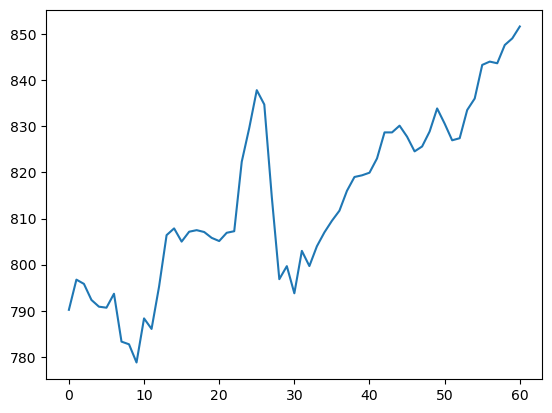

In [42]:
#3. Select open price column
dataset = data['Open'].values
print(dataset)

plt.plot(dataset)

#Convert into 2D array
dataset = dataset.reshape(-1,1)
print(dataset)

In [43]:
#4. Normalize data
scaler = MinMaxScaler(feature_range=(0,1))
dataset_scaled = scaler.fit_transform(dataset)
print(dataset_scaled)

[[0.15673043]
 [0.24656614]
 [0.23392901]
 [0.18612623]
 [0.16607182]
 [0.16304941]
 [0.2045332 ]
 [0.06208818]
 [0.05412092]
 [0.        ]
 [0.13118116]
 [0.09986292]
 [0.22596174]
 [0.37898394]
 [0.39903835]
 [0.35975284]
 [0.38914865]
 [0.3938185 ]
 [0.38832451]
 [0.37087919]
 [0.36140112]
 [0.38598874]
 [0.39065944]
 [0.59739008]
 [0.69793964]
 [0.81043971]
 [0.76785761]
 [0.4924448 ]
 [0.24793943]
 [0.28667581]
 [0.20590649]
 [0.33214281]
 [0.28695079]
 [0.34587907]
 [0.38722537]
 [0.42170354]
 [0.45178599]
 [0.51085177]
 [0.55206057]
 [0.55700542]
 [0.5648352 ]
 [0.60728063]
 [0.68475253]
 [0.68475253]
 [0.70480778]
 [0.67197789]
 [0.62829668]
 [0.64285708]
 [0.68736246]
 [0.75604379]
 [0.71085178]
 [0.66126405]
 [0.66744553]
 [0.75137393]
 [0.78557709]
 [0.88557751]
 [0.89546722]
 [0.89052237]
 [0.94478079]
 [0.96456104]
 [1.        ]]


In [44]:
#5. Creating training data
X_train = []
y_train = []

#Use previous 60 days to predict next day
for i in range(60, len(dataset_scaled)):
    X_train.append(dataset_scaled[i-60:i, 0])
    y_train.append(dataset_scaled[i,0])


#Convert into NumPy arrays
X_train = np.array(X_train)
print(X_train)
print(X_train.shape)
y_train = np.array(y_train)
print(y_train)
print(y_train.shape)

[[0.15673043 0.24656614 0.23392901 0.18612623 0.16607182 0.16304941
  0.2045332  0.06208818 0.05412092 0.         0.13118116 0.09986292
  0.22596174 0.37898394 0.39903835 0.35975284 0.38914865 0.3938185
  0.38832451 0.37087919 0.36140112 0.38598874 0.39065944 0.59739008
  0.69793964 0.81043971 0.76785761 0.4924448  0.24793943 0.28667581
  0.20590649 0.33214281 0.28695079 0.34587907 0.38722537 0.42170354
  0.45178599 0.51085177 0.55206057 0.55700542 0.5648352  0.60728063
  0.68475253 0.68475253 0.70480778 0.67197789 0.62829668 0.64285708
  0.68736246 0.75604379 0.71085178 0.66126405 0.66744553 0.75137393
  0.78557709 0.88557751 0.89546722 0.89052237 0.94478079 0.96456104]]
(1, 60)
[1.]
(1,)


In [46]:
#6. Reshape for RNN
#RNN expects 3D input
#(samples (Total training exaples, here 1), timesteps(sequence length, here considering 60 days), no of features(here only stock price))

print(X_train.shape[0])

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1],1)

1


In [16]:
#7. Build the model

model = Sequential()

#RNN Layer
model.add(SimpleRNN(units=50,activation='tanh', return_sequences=True, input_shape=(60,1)))
model.add(SimpleRNN(50))
model.add(Dense(1))

C:\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
#8. Compile Model
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
#9. Train Model
history = model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.8239
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0691
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0398
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.1786
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.2052
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.1419
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0606
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0092
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0022
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.0258
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 0.0528
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0637
Epoch 13/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0555
Epoch 14/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0357
Epoch 15/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0154
Epoch 16/20
1/1 ━━━━━━━━━━━━━━━━━

In [21]:

predicted = model.predit(X_test)

predicted = scaler.inverse_transform(predicted)
real = scaler.inverse_transform(y_test.reshape(-1,1))

NameError: name 'X_test' is not defined